In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
import os
df=pd.read_excel(f"C:/Users/{os.getlogin()}/Downloads/Netflix_user_behavior_fixed (1) (2).xlsx")
df.head()

,User_ID,Name,Age,Profile_Type,Gender,Country,Subscription_Plan,Favorite_Genre,Watch_Time_Hours_Per_Week,Device_Used,Monthly_Spend_USD,Join_Date,Last_Login,Movies_Watched_Per_Month,Binge_Watcher,Ratings_Given
0,1,James Kramer,20,Adult,Female,France,Basic,Action,14,Laptop,5.99,2021-06-21,2021-08-30,46,No,6
1,2,Erik Tucker,42,Adult,Male,Australia,Basic,Comedy,8,Smart TV,19.99,2024-11-25,2025-10-29,40,No,10
2,3,Mr. David Wilson,12,Kids,Male,India,Premium,Family,34,Mobile,5.99,2022-11-22,2024-02-23,9,No,9
3,4,Mark Garza,57,Adult,Male,Australia,Basic,Horror,24,Tablet,5.99,2023-09-26,2025-10-18,26,No,3
4,5,Courtney Curtis,15,Kids,Female,Australia,Basic,Family,17,Mobile,14.99,2025-04-02,2025-06-14,26,Yes,3


In [11]:
df.columns

Index(['User_ID', 'Name', 'Age', 'Profile_Type', 'Gender', 'Country',
       'Subscription_Plan', 'Favorite_Genre', 'Watch_Time_Hours_Per_Week',
       'Device_Used', 'Monthly_Spend_USD', 'Join_Date', 'Last_Login',
       'Movies_Watched_Per_Month', 'Binge_Watcher', 'Ratings_Given'],
      dtype='object')

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   User_ID                    3000 non-null   int64  
 1   Name                       3000 non-null   object 
 2   Age                        3000 non-null   int64  
 3   Profile_Type               3000 non-null   object 
 4   Gender                     3000 non-null   object 
 5   Country                    3000 non-null   object 
 6   Subscription_Plan          3000 non-null   object 
 7   Favorite_Genre             3000 non-null   object 
 8   Watch_Time_Hours_Per_Week  3000 non-null   int64  
 9   Device_Used                3000 non-null   object 
 10  Monthly_Spend_USD          3000 non-null   float64
 11  Join_Date                  3000 non-null   object 
 12  Last_Login                 3000 non-null   object 
 13  Movies_Watched_Per_Month   3000 non-null   int64

In [16]:
df.isnull().sum()

User_ID                      0
Name                         0
Age                          0
Profile_Type                 0
Gender                       0
Country                      0
Subscription_Plan            0
Favorite_Genre               0
Watch_Time_Hours_Per_Week    0
Device_Used                  0
Monthly_Spend_USD            0
Join_Date                    0
Last_Login                   0
Movies_Watched_Per_Month     0
Binge_Watcher                0
Ratings_Given                0
dtype: int64

In [28]:
#check total rows before dropping duplicates
print("Rows before:",df.shape[0])
#Drop duplicates
df.drop_duplicates(inplace=True)
#check total rows after dropping duplicates
print("Rows after:",df.shape[0])

Rows before: 3000
Rows after: 3000


In [25]:
df.shape

(3000, 16)

In [31]:
#strip extra whitespaces from columns names
df.columns=df.columns.str.strip()
#print names to confirm it executed successfully
df.columns

Index(['User_ID', 'Name', 'Age', 'Profile_Type', 'Gender', 'Country',
       'Subscription_Plan', 'Favorite_Genre', 'Watch_Time_Hours_Per_Week',
       'Device_Used', 'Monthly_Spend_USD', 'Join_Date', 'Last_Login',
       'Movies_Watched_Per_Month', 'Binge_Watcher', 'Ratings_Given'],
      dtype='object')

In [45]:
#check if the file is created and visible in the directory
import os
os.path.exists('netflix_user_clean.csv')

True

In [ ]:
# DATA VISUALIZATION

In [47]:
df=pd.read_csv('netflix_user_clean.csv')
print("Data Loaded successfully! Total rows:",df.shape[0])

Data Loaded successfully! Total rows: 3000


In [59]:
#fresh cleaned data load
df=pd.read_csv('netflix_user_clean.csv')
df['favoritegenre'].value_counts()

favoritegenre
Drama             308
Action            302
Horror            302
Documentary       292
Comedy            279
Romance           277
Thriller          263
Sci-Fi            240
Cartoon           162
Animation         149
Kids Adventure    148
Family            143
Fantasy           135
Name: count, dtype: int64

In [58]:
df.columns.tolist()

['userid',
 'name',
 'age',
 'profiletype',
 'gender',
 'country',
 'subscriptionplan',
 'favoritegenre',
 'watchtimehoursperweek',
 'deviceused',
 'monthlyspendusd',
 'joindate',
 'lastlogin',
 'movieswatchedpermonth',
 'bingewatcher',
 'ratingsgiven']

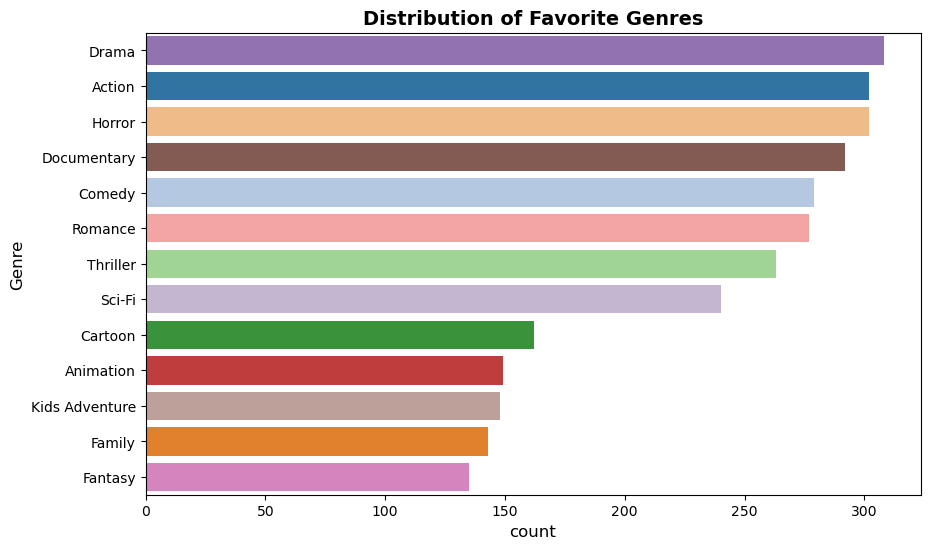

In [85]:
plt.figure(figsize=(10,6))
sns.countplot(y='favoritegenre',data=df,order=df['favoritegenre'].value_counts().index,hue='favoritegenre',palette='tab20',legend=False)
plt.title("Distribution of Favorite Genres",fontsize=14,fontweight='bold')
plt.xlabel("count",fontsize=12)
plt.ylabel("Genre",fontsize=12)
plt.show()


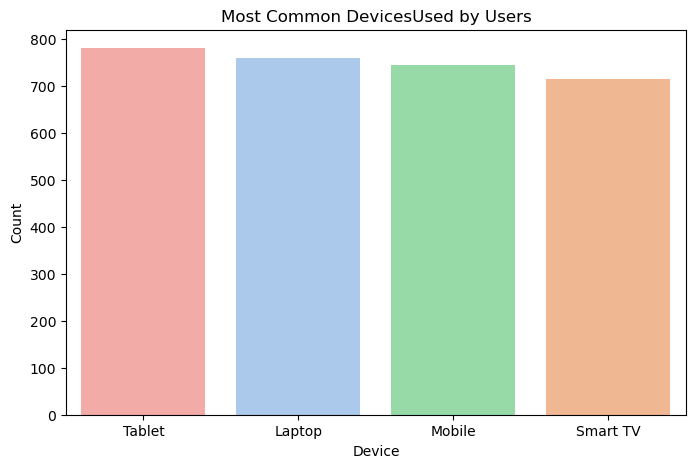

In [63]:
plt.figure(figsize=(8,5))
sns.countplot(x='deviceused',data=df,order=df['deviceused'].value_counts().index,hue='deviceused',palette='pastel',legend=False)
plt.title("Most Common DevicesUsed by Users")
plt.xlabel("Device")
plt.ylabel("Count")
plt.show()

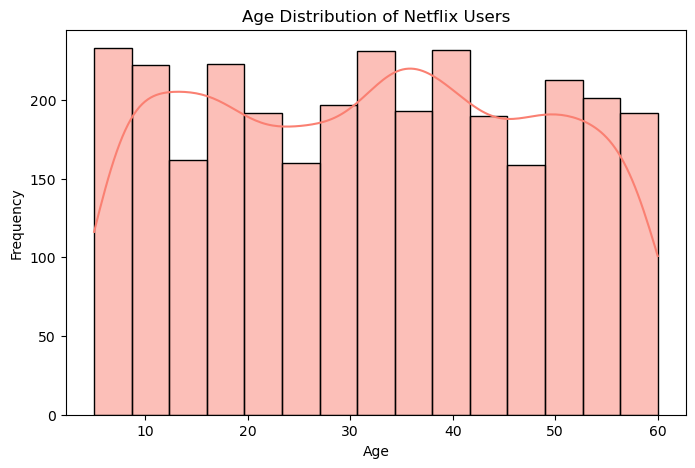

In [66]:
plt.figure(figsize=(8,5))
sns.histplot(df['age'],bins=15,kde=True,color='salmon')
plt.title("Age Distribution of Netflix Users")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

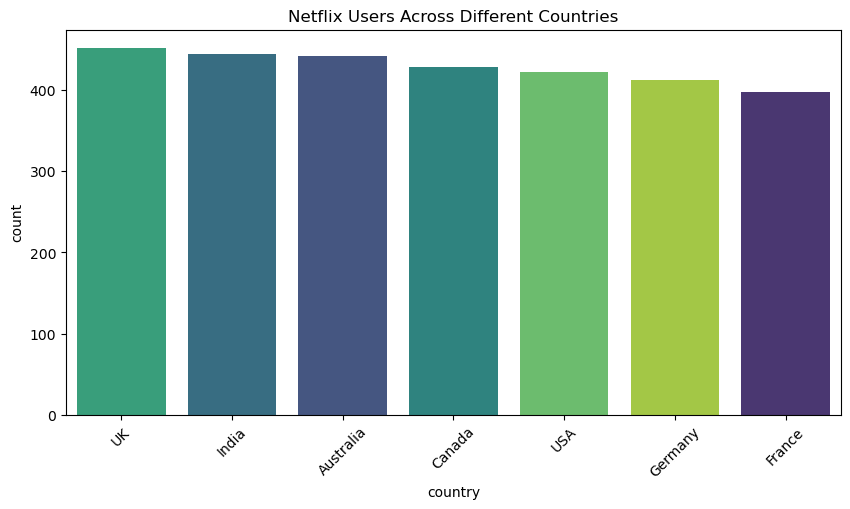

In [68]:
plt.figure(figsize=(10,5))
sns.countplot(x='country',data=df,order=df['country'].value_counts().index,hue='country',palette='viridis',legend=False)
plt.title("Netflix Users Across Different Countries")
plt.xticks(rotation=45)
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

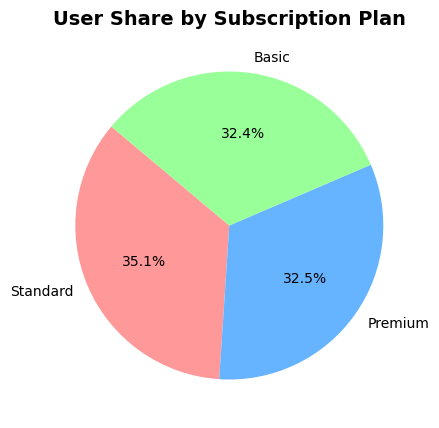

In [79]:
plt.figure(figsize=(6,5))
plan_counts=df['subscriptionplan'].value_counts()
plt.pie(plan_counts,labels=plan_counts.index,autopct='%1.1f%%',startangle=140,colors=['#ff9999','#66b3ff','#99ff99'])
plt.title("User Share by Subscription Plan",fontsize=14,fontweight='bold')
plt.show

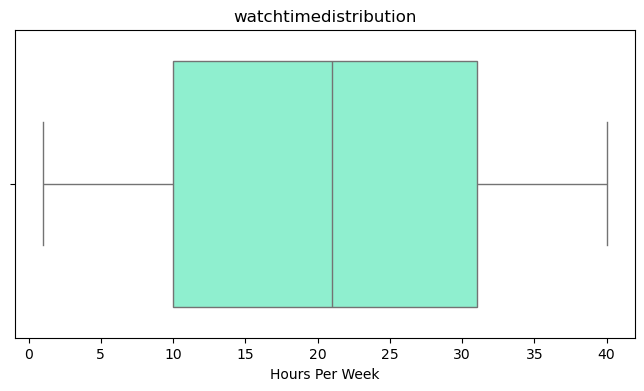

In [75]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df['watchtimehoursperweek'],color='aquamarine')
plt.title("watchtimedistribution")
plt.xlabel("Hours Per Week")
plt.show()